# 02 — Model A: Return Likelihood

Train a LightGBM classifier to predict `P(return | order features)` at order fulfillment time.

**Business use**: flag high-risk orders for enhanced quality checks before shipping;
build aggregate return forecasts by category/week.

In [1]:
import sys
import sys
from pathlib import Path
sys.path.insert(0, str(Path().resolve().parents[2] / "src"))   # commerce-ml-lab/src  (shared lib)
sys.path.insert(0, str(Path().resolve().parents[0] / "src"))   # 02_returns_intelligence/src
from pathlib import Path
sys.path.insert(0, str(Path().resolve().parents[2] / "src"))   # commerce-ml-lab/src  (shared lib)
sys.path.insert(0, str(Path().resolve().parents[0] / "src"))   # 02_returns_intelligence/src
import warnings; warnings.filterwarnings("ignore")
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from commerce_ml.viz.plotting import apply_style, PALETTE
from returns.likelihood import ReturnLikelihoodModel, RISK_THRESHOLDS
apply_style()
RESULTS = Path("../results"); RESULTS.mkdir(exist_ok=True)

customers = pd.read_parquet(RESULTS / "customers.parquet")
orders    = pd.read_parquet(RESULTS / "orders.parquet")
returns   = pd.read_parquet(RESULTS / "returns.parquet")
print(f"Loaded: {len(customers):,} customers, {len(orders):,} orders")

Loaded: 20,000 customers, 70,806 orders


## Train / test split — temporal

In [2]:
from sklearn.model_selection import train_test_split

# Temporal split: last 20% of orders by date as test
orders_sorted = orders.sort_values("order_date")
split_idx = int(len(orders_sorted) * 0.80)
train_orders = orders_sorted.iloc[:split_idx]
test_orders  = orders_sorted.iloc[split_idx:]

print(f"Train: {len(train_orders):,} orders | Test: {len(test_orders):,} orders")
print(f"Train return rate: {train_orders['was_returned'].mean():.1%}")
print(f"Test return rate:  {test_orders['was_returned'].mean():.1%}")

Train: 56,644 orders | Test: 14,162 orders
Train return rate: 14.8%
Test return rate:  14.6%


## Train the model

In [3]:
model = ReturnLikelihoodModel()
model.fit(train_orders, customers)
print(f"Features used: {model.feature_cols_}")
print(f"Calibration: {'on' if model.calibrator_ is not None else 'off'}")

Features used: ['item_price', 'quantity', 'account_age_days', 'customer_lifetime_return_rate', 'customer_total_orders', 'category', 'channel']
Calibration: on


## Evaluate: PR-AUC and calibration

PR-AUC:  0.5806  (random baseline = 0.1464)
ROC-AUC: 0.8908

Risk threshold settings: {'low': 0.1, 'medium': 0.25}


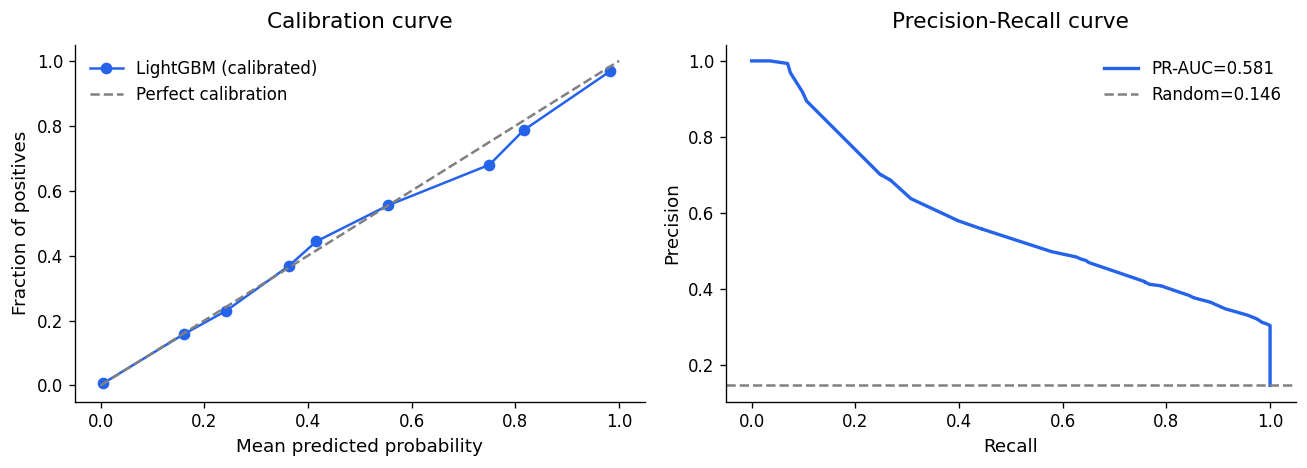

In [4]:
from sklearn.metrics import roc_auc_score
from commerce_ml.evaluation.classification_metrics import pr_auc

proba = model.predict_proba(test_orders, customers)
y_true = test_orders["was_returned"].astype(int).values

prauc = pr_auc(y_true, proba)
rocauc = roc_auc_score(y_true, proba)
print(f"PR-AUC:  {prauc:.4f}  (random baseline = {y_true.mean():.4f})")
print(f"ROC-AUC: {rocauc:.4f}")
print(f"\nRisk threshold settings: {RISK_THRESHOLDS}")

# Plot calibration curve + PR curve
from sklearn.calibration import calibration_curve
from sklearn.metrics import precision_recall_curve

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

# Calibration curve
frac_pos, mean_pred = calibration_curve(y_true, proba, n_bins=10)
axes[0].plot(mean_pred, frac_pos, "o-", color=PALETTE[0], label="LightGBM (calibrated)")
axes[0].plot([0,1],[0,1], "--", color="grey", label="Perfect calibration")
axes[0].set_xlabel("Mean predicted probability")
axes[0].set_ylabel("Fraction of positives")
axes[0].set_title("Calibration curve")
axes[0].legend()

# PR curve
prec, rec, _ = precision_recall_curve(y_true, proba)
axes[1].plot(rec, prec, color=PALETTE[0], linewidth=2, label=f"PR-AUC={prauc:.3f}")
axes[1].axhline(y_true.mean(), color="grey", linestyle="--", label=f"Random={y_true.mean():.3f}")
axes[1].set_xlabel("Recall"); axes[1].set_ylabel("Precision")
axes[1].set_title("Precision-Recall curve")
axes[1].legend()

plt.tight_layout()
plt.savefig(RESULTS / "likelihood_evaluation.png", dpi=120)
plt.show()

## Risk tier distribution

In [5]:
result = model.predict_with_tier(test_orders, customers)
tier_counts = result["risk_tier"].value_counts()
print("Risk tier distribution:")
print(tier_counts)
print(f"\nReturn rate by tier:")
test_with_tiers = test_orders.copy().reset_index(drop=True)
test_with_tiers["risk_tier"] = result["risk_tier"].values
print(test_with_tiers.groupby("risk_tier")["was_returned"].mean().sort_values(ascending=False))

model.save(RESULTS / "likelihood_model.pkl")
print(f"\nModel saved to results/likelihood_model.pkl")

Risk tier distribution:
risk_tier
low       7878
high      3866
medium    2418
Name: count, dtype: int64

Return rate by tier:
risk_tier
high      0.412054
medium    0.176592
low       0.006728
Name: was_returned, dtype: float64

Model saved to results/likelihood_model.pkl
